In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, KBinsDiscretizer
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

print(f" {df} Columns ")
print(list(df.columns))


      Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6   Overweight   
1               

In [3]:
print(f"{len(df)} ")

rows, columns = df.shape
print(f"Το dataset έχει {rows} γραμμές και {columns} στήλες.")

374 
Το dataset έχει 374 γραμμές και 13 στήλες.


In [4]:
pd.set_option('display.max_columns', None)
display(df.head())

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## ΚΑΘΑΡΙΣΜΟΣ ΔΕΔΟΜΕΝΩΝ

Αρχικά, θα διαχωρίσω την πίεση του αίματος σε συστολική και διαστολική χωρίζοντας τη στήλη Blood Pressure σε 2 στήλες:

In [5]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)

df['Systolic'] = pd.to_numeric(df['Systolic'])
df['Diastolic'] = pd.to_numeric(df['Diastolic'])

df = df.drop('Blood Pressure', axis=1)
display(df.head())

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [6]:
print(df['BMI Category'].unique())
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')
display(df.head())

<StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


Παρατηρώντας τα Δεδομένα οι στήλες Gender Occupation BMICategory SleepDisorder είναι ποιοτικές μεταβλητές
Ενώ οι Age SleepDuration QualityofSleep PhysicalActivityLevel StressLevel HeartRate DailySteps Systolic Diastolic είναι ποσοτικές.

Οι αλγόριθμοι καταλαβαίνουν μόνο αριθμούς και αποστάσεις. Άρα πρέπει να μετατρέψουμε τις ποιοτικές μεταβλημτές σε ποσοτικές.

In [7]:
categorical_cols = ['Gender', 'Occupation', 'BMI Category']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

display(df.head())

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic,Gender_Male,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Obese,BMI Category_Overweight
0,1,27,6.1,6,42,6,77,4200,NaN,126,83,True,False,False,False,False,False,False,False,False,True,False,False,True
1,2,28,6.2,6,60,8,75,10000,NaN,125,80,True,True,False,False,False,False,False,False,False,False,False,False,False
2,3,28,6.2,6,60,8,75,10000,NaN,125,80,True,True,False,False,False,False,False,False,False,False,False,False,False
3,4,28,5.9,4,30,8,85,3000,Sleep Apnea,140,90,True,False,False,False,False,False,True,False,False,False,False,True,False
4,5,28,5.9,4,30,8,85,3000,Sleep Apnea,140,90,True,False,False,False,False,False,True,False,False,False,False,True,False


In [8]:
print("Κενές τιμές ανά στήλη:")
print(df.isnull().sum())

duplicates_count = df.duplicated().sum()
print(f"Συνολικές διπλότυπες γραμμές στο dataset: {duplicates_count}")

Κενές τιμές ανά στήλη:
Person ID                            0
Age                                  0
Sleep Duration                       0
Quality of Sleep                     0
Physical Activity Level              0
Stress Level                         0
Heart Rate                           0
Daily Steps                          0
Sleep Disorder                     219
Systolic                             0
Diastolic                            0
Gender_Male                          0
Occupation_Doctor                    0
Occupation_Engineer                  0
Occupation_Lawyer                    0
Occupation_Manager                   0
Occupation_Nurse                     0
Occupation_Sales Representative      0
Occupation_Salesperson               0
Occupation_Scientist                 0
Occupation_Software Engineer         0
Occupation_Teacher                   0
BMI Category_Obese                   0
BMI Category_Overweight              0
dtype: int64
Συνολικές διπλότυπες γραμμές

In [9]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

print("Κατανομή των κατηγοριών διαταραχής ύπνου:")
print(df['Sleep Disorder'].value_counts())

Κατανομή των κατηγοριών διαταραχής ύπνου:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


## 'Ελεγχος για ακραίες τιμές

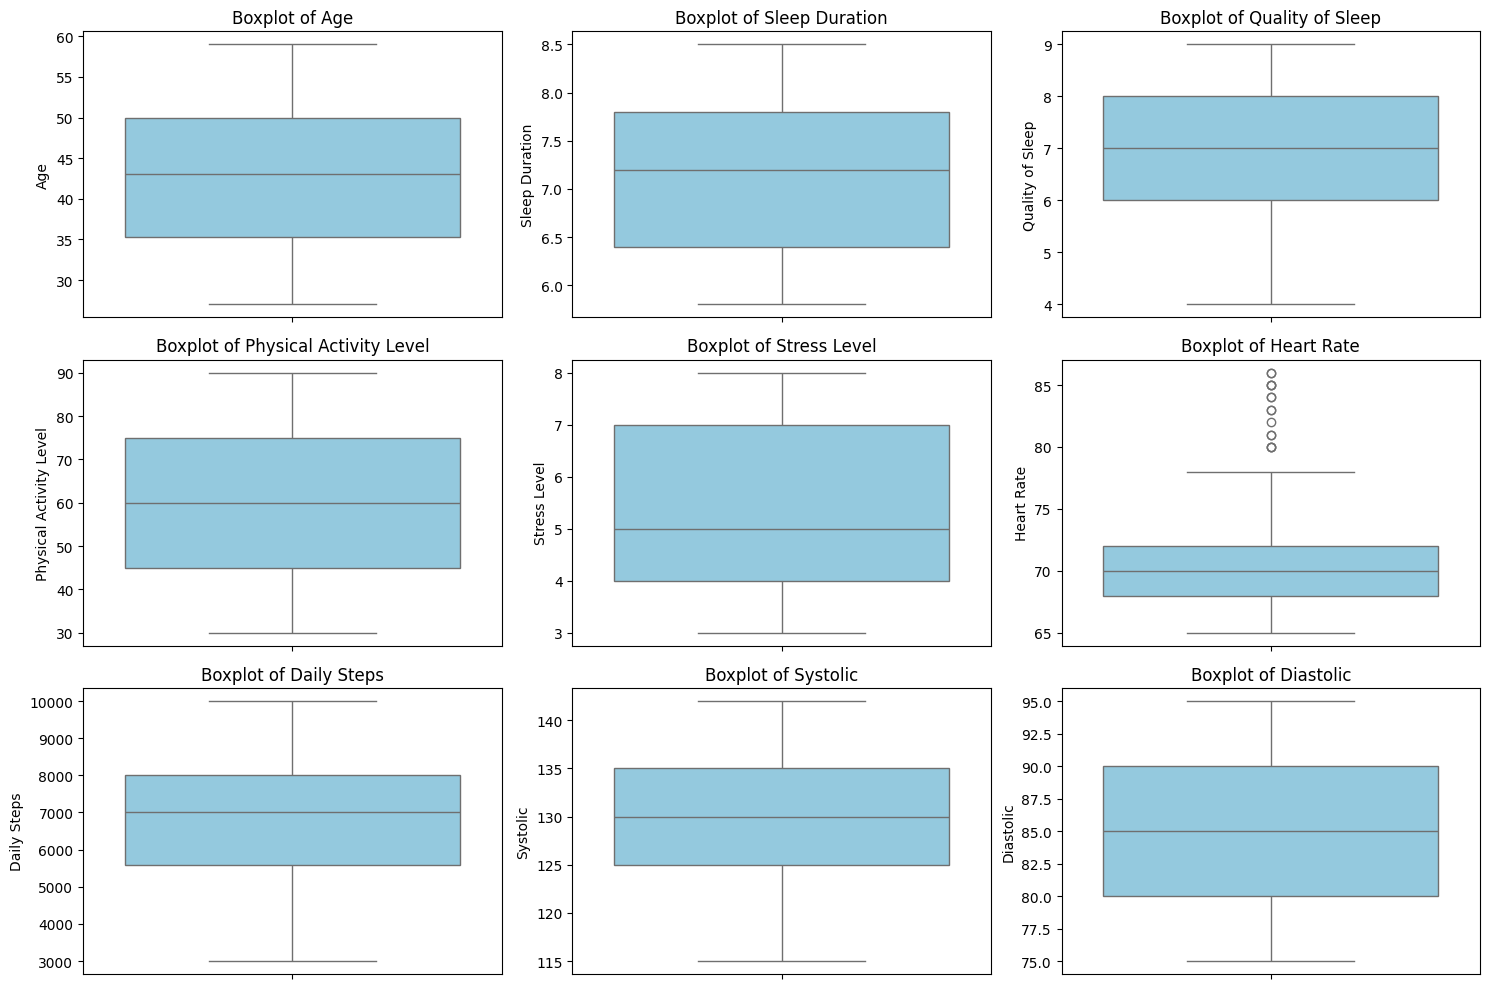

In [10]:
numeric_columns_to_check = ['Age', 'Sleep Duration', 'Quality of Sleep', 
                            'Physical Activity Level', 'Stress Level', 
                            'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

#boxplot
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_columns_to_check, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Για τον εντοπισμό πιθανών ακραίων τιμών (outliers) στο σύνολο δεδομένων, δημιουργήθηκαν θηκογράμματα (boxplots) για όλες τις συνεχείς αριθμητικές μεταβλητές.

**Παρατηρήσεις και Ανάλυση:**
*  Όπως φαίνεται στα διαγράμματα, οι μεταβλητές `Age`, `Sleep Duration`, `Quality of Sleep`, `Physical Activity Level`, `Stress Level`, `Daily Steps`, `Systolic` και `Diastolic` παρουσιάζουν μια εξαιρετικά ομαλή κατανομή. Δεν παρατηρείται καμία τιμή εκτός των ορίων, που δείχνει υψηλή ποιότητα δεδομένων χωρίς σφάλματα καταχώρησης.
*  Η μοναδική μεταβλητή που παρουσιάζει ακραίες τιμές είναι ο Καρδιακός Ρυθμός (`Heart Rate`), όπου εντοπίζεται μια ομάδα ατόμων με παλμούς ηρεμίας άνω των 80 bpm.

**Απόφαση Διαχείρισης:**
Αποφασίστηκε η **διατήρηση** αυτών των ακραίων τιμών στο σύνολο δεδομένων χωρίς καμία τροποποίηση ή διαγραφή. Δεδομένου ότι αναλύουμε ιατρικά δεδομένα, η ταχυκαρδία δεν αποτελεί θόρυβο ή λάθος. Η αφαίρεσή τους θα στερούσε από τα μοντέλα ταξινόμησης πολύτιμη πληροφορία, μειώνοντας την ακρίβεια.

In [11]:
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

#Κανονικοποίηση
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Train-Test Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "k-Nearest Neighbors (kNN)": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    #Εκπαίδευση 
    model.fit(X_train_resampled, y_train_resampled)
    
    #Πρόβλεψη
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f" {name} ")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    print("-" * 55 + "\n")

for name, acc in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {acc*100:.2f}%")

 Decision Tree 
Accuracy: 0.8933

              precision    recall  f1-score   support

    Insomnia       0.72      0.87      0.79        15
        None       0.98      0.95      0.97        44
 Sleep Apnea       0.86      0.75      0.80        16

    accuracy                           0.89        75
   macro avg       0.85      0.86      0.85        75
weighted avg       0.90      0.89      0.89        75

-------------------------------------------------------

 k-Nearest Neighbors (kNN) 
Accuracy: 0.9067

              precision    recall  f1-score   support

    Insomnia       0.80      0.80      0.80        15
        None       1.00      0.91      0.95        44
 Sleep Apnea       0.80      1.00      0.89        16

    accuracy                           0.91        75
   macro avg       0.87      0.90      0.88        75
weighted avg       0.92      0.91      0.91        75

-------------------------------------------------------

 Naive Bayes 
Accuracy: 0.9200

            

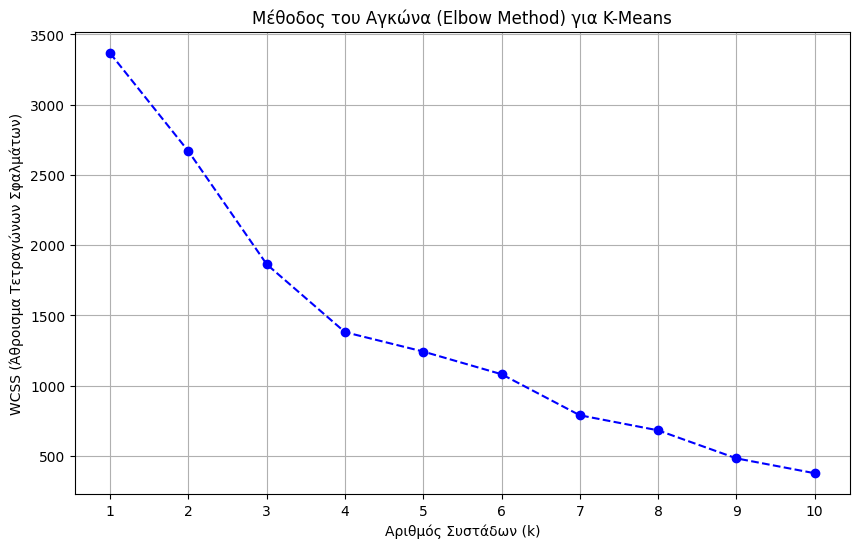

In [12]:
clusters = ['Age', 'Sleep Duration', 'Quality of Sleep', 
                    'Physical Activity Level', 'Stress Level', 
                    'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

X_cluster = df[clusters]

# Κανονικοποίηση
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

#Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Μέθοδος του Αγκώνα (Elbow Method) για K-Means')
plt.xlabel('Αριθμός Συστάδων (k)')
plt.ylabel('WCSS (Άθροισμα Τετραγώνων Σφαλμάτων)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

k=4 

In [13]:
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init='auto')

clusters = kmeans_final.fit_predict(X_cluster_scaled)

df_cluster_analysis = X_cluster.copy()
df_cluster_analysis['Cluster_KMeans'] = clusters

cluster_profiles = df_cluster_analysis.groupby('Cluster_KMeans').mean()

display(cluster_profiles.round(1))

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,Diastolic
Cluster_KMeans,,,,,,,,,
0,40.0,7.7,8.0,63.5,4.5,68.2,7137.1,123.4,80.6
1,51.8,7.4,8.1,61.8,3.5,67.4,6393.5,137.8,92.7
2,37.8,6.4,6.0,40.4,7.2,73.8,5516.7,128.4,83.6
3,49.8,6.1,6.0,90.0,8.0,75.0,10000.0,140.0,95.0


### Ανάλυση Προφίλ Συστάδων (K-Means, k=4)

Από την εφαρμογή του αλγορίθμου K-Means, προέκυψαν 4 διακριτές ομάδες (clusters) με τα εξής χαρακτηριστικά:

* **Συστάδα 0 Η Ισορροπημένη Ομάδα Μέσης Ηλικίας:** 
Αποτελείται από άτομα μέσης ηλικίας (περίπου 40 ετών) που έχουν την πιο υγιή ρουτίνα.Έχουν τη μεγαλύτερη διάρκεια ύπνου (7.7 ώρες) με πολύ καλή ποιότητα (8.0). Έχουν μέτρια φυσική δραστηριότητα, χαμηλό καρδιακό ρυθμό (68.2) και απόλυτα φυσιολογική αρτηριακή πίεση (123/80). Το στρες τους κυμαίνεται σε μέτρια προς χαμηλά επίπεδα (4.5).

* **Συστάδα 1 Η Μεγαλύτερη Ηλικιακά Ομάδα με Καλό Ύπνο αλλά Αυξημένη Πίεση:** 
Πρόκειται για τους μεγαλύτερους σε ηλικία συμμετέχοντες (περίπου 52 ετών). Το εντυπωσιακό χαρακτηριστικό τους είναι ότι, παρά την ηλικία τους, έχουν το χαμηλότερο επίπεδο στρες (3.5) και την υψηλότερη ποιότητα ύπνου (8.1). Ωστόσο, κάνουν τα λιγότερα βήματα/δραστηριότητα και παρουσιάζουν αρκετά αυξημένη αρτηριακή πίεση (138/92), το οποίο πιθανότατα οφείλεται στην ηλικία και την καθιστική ζωή.

* **Συστάδα 2 Η Νεαρή Ομάδα με Καθιστική Ζωή και Στρες:**
Αυτή η ομάδα περιλαμβάνει τα νεότερα άτομα του δείγματος (περίπου 38 ετών). Χαρακτηρίζονται από έντονη καθιστική ζωή (το χαμηλότερο Physical Activity 40.4 και 5516 βήματα). Παρουσιάζουν υψηλά επίπεδα στρες (7.2), γεγονός που αντανακλάται στην κακή ποιότητα (6.0) και τη μικρή διάρκεια ύπνου (6.4 ώρες). 

* **Συστάδα 3 Η Υπερδραστήρια αλλά Υψηλά Στρεσαρισμένη Ομάδα:**
Άτομα ηλικίας ~50 ετών, τα οποία καταγράφουν την πιό υψηλότερη φυσική δραστηριότητα (επίπεδο 90, 10000 βήματα) αλλά καταγράφουν το απόλυτο μέγιστο στο επίπεδο στρες (8.0).Έτσι κοιμούνται λιγότερο από όλους (6.1 ώρες), και έχουν τον υψηλότερο καρδιακό ρυθμό ηρεμίας (75 bpm) και υπέρταση (140/95).

Ιεραρχική Συσταδοποίηση & Δενδρόγραμμα

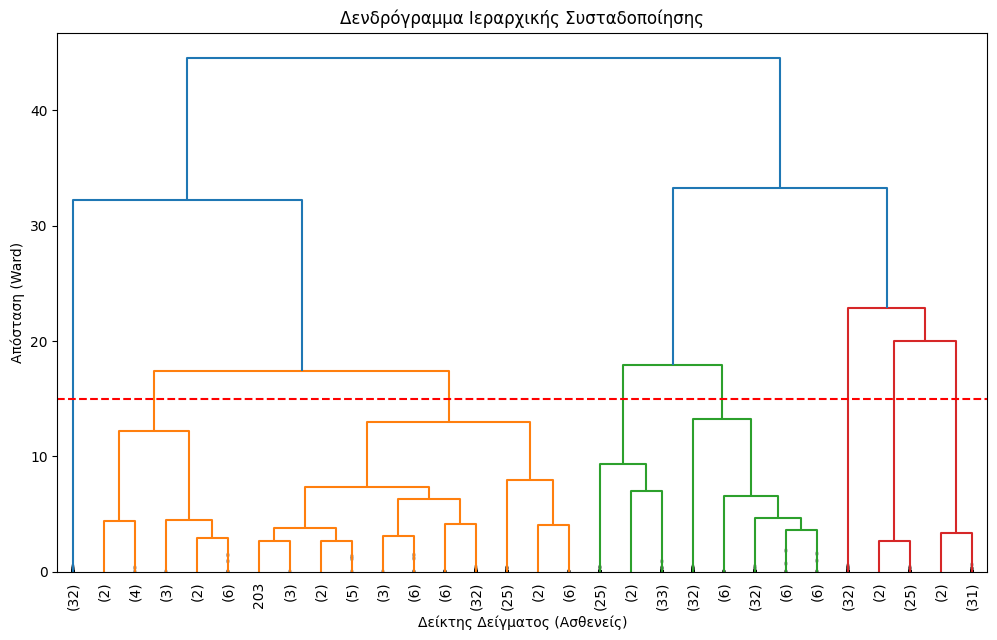

In [14]:
Z = linkage(X_cluster_scaled, method='ward')

plt.figure(figsize=(12, 7))
plt.title('Δενδρόγραμμα Ιεραρχικής Συσταδοποίησης')
plt.xlabel('Δείκτης Δείγματος (Ασθενείς)')
plt.ylabel('Απόσταση (Ward)')

dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)

plt.axhline(y=15, color='r', linestyle='--')
plt.show()

### Ιεραρχική Συσταδοποίηση (Agglomerative Clustering)

Εφαρμόστηκε ο αλγόριθμος Ιεραρχικής Συσταδοποίησης με χρήση του κριτηρίου ελαχιστοποίησης της διακύμανσης του Ward.

**Ανάλυση Δενδρογράμματος & Επιλογή Συστάδων:**
Στο δενδρόγραμμα, ο κατακόρυφος άξονας (Απόσταση Ward) δείχνει τον βαθμό ανομοιότητας μεταξύ των ομάδων που ενώνονται. Παρατηρούμε ότι οι ενώσεις σε χαμηλά επίπεδα απόστασης (κάτω του 20) είναι πολλές. 

Αναζητώντας τη μεγαλύτερη κατακόρυφη απόσταση χωρίς διακλαδώσεις, τοποθετήσαμε μια οριζόντια διακεκκωμένη γραμμή στο ύψος `y=25`. Σε αυτό το ύψος, η νοητή γραμμή τέμνει ακριβώς **4 κάθετους κλάδους**. 

Έτσι, επιβεβαιώνεται οτι το βέλτιστο πλήθος συστάδων για τα συγκεκριμένα δεδομένα καθορίζεται οριστικά σε **k=4**.

## DBSCAN

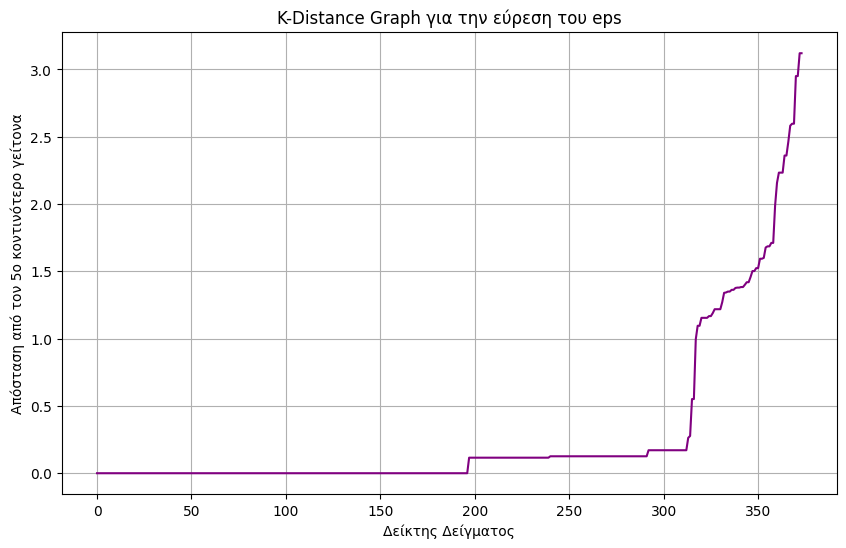

In [15]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_cluster_scaled)

distances, indices = neighbors_fit.kneighbors(X_cluster_scaled)

distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances, color='purple')
plt.title('K-Distance Graph για την εύρεση του eps')
plt.xlabel('Δείκτης Δείγματος')
plt.ylabel('Απόσταση από τον 5ο κοντινότερο γείτονα')
plt.grid(True)
plt.show()

In [16]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

# Πρόβλεψη
clusters_dbscan = dbscan.fit_predict(X_cluster_scaled)

df_cluster_analysis['Cluster_DBSCAN'] = clusters_dbscan

print("Κατανομή ατόμων στις συστάδες (Το -1 αντιπροσωπεύει τον θόρυβο / outliers):\n")
print(df_cluster_analysis['Cluster_DBSCAN'].value_counts().sort_index())

Κατανομή ατόμων στις συστάδες (Το -1 αντιπροσωπεύει τον θόρυβο / outliers):

Cluster_DBSCAN
-1     19
 0    138
 1      6
 2     25
 3      6
 4     25
 5     33
 6     27
 7     32
 8     32
 9     31
Name: count, dtype: int64


### Συσταδοποίηση με DBSCAN

Ο DBSCAN είναι βασισμένος στην πυκνότητα (density-based) και έχει το πλεονέκτημα ότι δεν απαιτεί εκ των προτέρων καθορισμό του αριθμού των συστάδων, ενώ παράλληλα εντοπίζει τις ακραίες τιμές (outliers).

**Επιλογή Παραμέτρων:**
* **`min_samples = 5`**: Επιλέχθηκε ως μια συντηρητική προσέγγιση (ελάχιστο μέγεθος γειτονιάς) για ένα σχετικά μικρό dataset, ώστε να αποφευχθεί η δημιουργία υπερβολικά πολλών μικρο-συστάδων.
* **`eps = 1.5`**: Η τιμή αυτή εξήχθη από το K-distance graph. Αναζητήθηκε το σημείο μέγιστης καμπυλότητας (αγκώνας) ακριβώς πριν η απόσταση από τον 5ο κοντινότερο γείτονα αυξηθεί εκθετικά, το οποίο εντοπίστηκε στο ύψος του 1.5.

**Ανάλυση Αποτελεσμάτων:**
Η εφαρμογή του αλγορίθμου αποκάλυψε μια εντελώς διαφορετική δομή στα δεδομένα σε σχέση με τον K-Means:
1. **Εντοπισμός Θορύβου (Outliers):** Ο αλγόριθμος ταξινόμησε 19 εγγραφές στην κλάση `-1`. Αυτό επιβεβαιώνει την αρχική μας ανάλυση κατά την προεπεξεργασία (μέσω των boxplots), όπου είχαμε εντοπίσει άτομα με πολύ υψηλούς καρδιακούς παλμούς. Ο DBSCAN απομόνωσε αυτά τα άτομα σωστά.
2. **Δημιουργία Συστάδων (Clusters 0 έως 9):** Δημιουργήθηκαν 10 διακριτές συστάδες. Η μεγαλύτερη συστάδα (Ομάδα 0) περιλαμβάνει 138 άτομα, τα οποία πιθανότατα αντιπροσωπεύουν τον "μέσο όρο" (τον πιο συνηθισμένο τρόπο ζωής). Οι υπόλοιπες συστάδες (από 25 έως 33 άτομα η καθεμία) αντιπροσωπεύουν πολύ συγκεκριμένα και σφιχτά προφίλ ανθρώπων με παρόμοιες συνήθειες. Οι ομάδες 1 και 3 (με μόλις 6 άτομα) οριακά ξεπέρασαν το κατώφλι του `min_samples`.

## Διακριτοποίηση κσι προετοιμασία των δεδομένων για τον αλγόριθμο Apriori

In [19]:
df_apriori = df.copy()

# numeric columns
num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 
            'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

# Discretization Low, Medium, High
for col in num_cols:
    df_apriori[col] = pd.qcut(df_apriori[col], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

#  0/1 One-Hot Encoding
df_apriori = pd.get_dummies(df_apriori, columns=num_cols)

# Disorder  0/1
df_apriori = pd.get_dummies(df_apriori, columns=['Sleep Disorder'])

df_apriori = df_apriori.astype(bool)

print("refactor successfull\n")
print(list(df_apriori.columns)[:15]) 
print(f"\n columns count'): {df_apriori.shape[1]}")

refactor successfull

['Person ID', 'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Salesperson', 'Occupation_Scientist', 'Occupation_Software Engineer', 'Occupation_Teacher', 'BMI Category_Obese', 'BMI Category_Overweight', 'Age_Low']

 columns count'): 44


In [21]:
# delete personID because this may confuse the algorithm
df_apriori = df_apriori.drop('Person ID', axis=1, errors='ignore')

In [24]:
frequent_itemsets = apriori(df_apriori, min_support=0.15, use_colnames=True)

#min Confidence 70%
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# sort by Lift and Confidence
rules_sorted = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

print("1o most interesting rules \n")

top_10_rules = rules_sorted.head(10)

for index, row in top_10_rules.iterrows():
    # refactor frozensets in strings
    antecedents = ", ".join(list(row['antecedents']))
    consequents = ", ".join(list(row['consequents']))
    
    print(f"rule {index}: if [ {antecedents} ]  --->  then [ {consequents} ]")
    print(f"  • Support : {row['support']:.3f} ({(row['support']*100):.1f}%)")
    print(f"  • Confidence : {row['confidence']:.3f} ({(row['confidence']*100):.1f}%)")
    print(f"  • Lift: {row['lift']:.3f}\n")

1o most interesting rules 

rule 2271: if [ Diastolic_Medium, Quality of Sleep_Medium ]  --->  then [ Systolic_Medium, Daily Steps_Medium ]
  • Support : 0.155 (15.5%)
  • Confidence : 1.000 (100.0%)
  • Lift: 6.448

rule 2272: if [ Diastolic_Medium, Daily Steps_Medium ]  --->  then [ Quality of Sleep_Medium, Systolic_Medium ]
  • Support : 0.155 (15.5%)
  • Confidence : 1.000 (100.0%)
  • Lift: 6.448

rule 2273: if [ Quality of Sleep_Medium, Systolic_Medium ]  --->  then [ Diastolic_Medium, Daily Steps_Medium ]
  • Support : 0.155 (15.5%)
  • Confidence : 1.000 (100.0%)
  • Lift: 6.448

rule 2274: if [ Systolic_Medium, Daily Steps_Medium ]  --->  then [ Diastolic_Medium, Quality of Sleep_Medium ]
  • Support : 0.155 (15.5%)
  • Confidence : 1.000 (100.0%)
  • Lift: 6.448

rule 3457: if [ Gender_Male, Systolic_Medium, Daily Steps_Medium ]  --->  then [ Diastolic_Medium, Quality of Sleep_Medium ]
  • Support : 0.155 (15.5%)
  • Confidence : 1.000 (100.0%)
  • Lift: 6.448

rule 3458: if 

Από την εκτέλεση του αλγορίθμου Apriori (min_support=15%, min_confidence=70%), παρατηρούμε οτι:
* Ταξινομώντας τους κανόνες με βάση το Lift, προέκυψε ότι οι 10 ισχυρότεροι κανόνες (όλοι με Confidence 100% και πολύ υψηλό Lift 6.448) περιγράφουν πρακτικά **το ίδιο ακριβώς ιατρικό προφίλ**.

* αφορά το 15.5% (Support) του συνολικού δείγματος. 

**Ανάλυση του "Μέσου Προφίλ":**
Οι κανόνες 2271-2274 και 3457-3468 αποδεικνύουν ότι η μεσαία/φυσιολογική αρτηριακή πίεση (Systolic/Diastolic Medium) συσχετίζεται απόλυτα με μια μέτρια φυσική δραστηριότητα (Daily Steps Medium) και μεσαία ποιότητα ύπνου (Quality of Sleep Medium). Οι κανόνες της σειράς 3457 προσθέτουν το Φύλο (Gender_Male), δείχνοντας ότι αυτό το συγκεκριμένο μοτίβο τρόπου ζωής αφορά κυρίως στους άνδρες του δείγματος.

**Συμπέρασμα:** Το εξαιρετικά υψηλό Lift (6.448) επιβεβαιώνει ιατρικά ότι η διατήρηση της καθημερινής κίνησης (έστω και σε μεσαία επίπεδα) συνδέεται άμεσα με τη φυσιολογική αρτηριακή πίεση και την καλή ποιότητα ύπνου. Το γεγονός ότι το Confidence είναι 100%, σημαίνει ότι σε αυτό το dataset, όποιος είχε αυτόν τον συνδυασμό πίεσης και βημάτων, δεν είχε ποτέ κακή ποιότητα ύπνου.